# CycleResearcher 系统实验分析

本notebook包含三个核心实验：
1. **实验1：模型对比** - 比较 CycleReviewer 8B 和 DeepReviewer 7B 的评审差异
2. **实验2：迭代改进** - 验证循环改进机制的有效性
3. **实验4：评审模式对比** - 对比 Fast Mode 和 Standard Mode 的效果

所有实验使用量化指标进行评估，无需人工主观判断。

---

## 🚀 使用指南

### 步骤1：检查GPU资源
运行第2个单元格查看可用GPU及显存情况

### 步骤2：配置GPU分配
- **如果有2个或以上GPU**：修改第2个单元格中的 `GPU_FOR_CYCLE_REVIEWER` 和 `GPU_FOR_DEEP_REVIEWER`
- **如果只有1个GPU**：需要串行运行实验（详见下方说明）

### 步骤3：依次运行单元格
按顺序运行所有单元格即可

---

## ⚠️ 显存不足解决方案

如果遇到 `RuntimeError: Engine core initialization failed` 错误：

**方案A：使用多个GPU（推荐）**
```python
GPU_FOR_CYCLE_REVIEWER = "0"  # 第一个模型用GPU 0
GPU_FOR_DEEP_REVIEWER = "1"   # 第二个模型用GPU 1
```

**方案B：降低显存占用**
- 将 `gpu_memory_utilization` 从 0.85 降低到 0.7 或 0.6
- 使用更小的模型（如 DeepReviewer-7B 而非 14B）

**方案C：串行运行（单GPU）**
1. 先运行实验1，完成后重启kernel释放显存
2. 然后运行实验2和4

**方案D：使用CPU（最慢但最稳定）**
- 将 `device="cuda"` 改为 `device="cpu"`

## ⚙️ GPU 配置说明

为避免显存溢出，我们需要将不同模型分配到不同的GPU上运行。

**推荐配置：**
- **方案1**（推荐）：为每个模型单独分配GPU
  - CycleReviewer 8B → GPU 0
  - DeepReviewer 7B → GPU 1
  
- **方案2**：如果GPU较少，串行运行实验
  - 先运行实验1（模型对比），完成后释放显存
  - 再运行实验2和实验4

**注意事项：**
1. 检查可用GPU：运行 `nvidia-smi` 查看GPU状态
2. 根据实际情况修改下面的GPU编号
3. 如果显存仍不足，可以降低 `gpu_memory_utilization` 参数（如0.7）

In [12]:
# GPU 配置检查和设置
import subprocess
import os

# 查看可用的GPU
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=index,name,memory.total,memory.free', 
                           '--format=csv,noheader'], 
                          capture_output=True, text=True)
    print("🔍 可用GPU列表：")
    print("=" * 80)
    lines = result.stdout.strip().split('\n')
    for line in lines:
        parts = line.split(', ')
        if len(parts) >= 4:
            gpu_id, name, total, free = parts[0], parts[1], parts[2], parts[3]
            print(f"GPU {gpu_id}: {name}")
            print(f"  总显存: {total}, 可用: {free}")
    print("=" * 80)
except Exception as e:
    print(f"⚠️ 无法获取GPU信息: {e}")

print("\n" + "=" * 80)
print("⚙️ GPU 分配策略设置")
print("=" * 80)

# ====== 在这里修改GPU分配 ======
GPU_FOR_CYCLE_REVIEWER = "3"  # CycleReviewer使用的GPU编号
GPU_FOR_DEEP_REVIEWER = "4"   # DeepReviewer使用的GPU编号
USE_SEPARATE_GPUS = True       # True=使用不同GPU, False=使用相同GPU（需要更多显存）

print(f"\n📌 当前配置：")
if USE_SEPARATE_GPUS:
    print(f"  ✓ 多GPU模式（推荐）")
    print(f"    - CycleReviewer 8B → GPU {GPU_FOR_CYCLE_REVIEWER}")
    print(f"    - DeepReviewer 7B  → GPU {GPU_FOR_DEEP_REVIEWER}")
else:
    print(f"  ⚠️ 单GPU模式（需要较大显存）")
    print(f"    - 两个模型都运行在 GPU {GPU_FOR_CYCLE_REVIEWER}")

print(f"\n💡 提示：")
print(f"  - 如需修改，请编辑上面的 GPU_FOR_CYCLE_REVIEWER 和 GPU_FOR_DEEP_REVIEWER")
print(f"  - 如果显存不足，将 gpu_memory_utilization 降低到 0.6-0.7")
print("=" * 80)

🔍 可用GPU列表：
GPU 0: NVIDIA GeForce RTX 5090
  总显存: 32607 MiB, 可用: 32095 MiB
GPU 1: NVIDIA GeForce RTX 5090
  总显存: 32607 MiB, 可用: 1165 MiB
GPU 2: NVIDIA GeForce RTX 5090
  总显存: 32607 MiB, 可用: 507 MiB
GPU 3: NVIDIA GeForce RTX 5090
  总显存: 32607 MiB, 可用: 32095 MiB
GPU 4: NVIDIA GeForce RTX 5090
  总显存: 32607 MiB, 可用: 32095 MiB
GPU 5: NVIDIA GeForce RTX 5090
  总显存: 32607 MiB, 可用: 3761 MiB
GPU 6: NVIDIA GeForce RTX 5090
  总显存: 32607 MiB, 可用: 31363 MiB
GPU 7: NVIDIA GeForce RTX 5090
  总显存: 32607 MiB, 可用: 661 MiB

⚙️ GPU 分配策略设置

📌 当前配置：
  ✓ 多GPU模式（推荐）
    - CycleReviewer 8B → GPU 3
    - DeepReviewer 7B  → GPU 4

💡 提示：
  - 如需修改，请编辑上面的 GPU_FOR_CYCLE_REVIEWER 和 GPU_FOR_DEEP_REVIEWER
  - 如果显存不足，将 gpu_memory_utilization 降低到 0.6-0.7


In [13]:
# 导入必要的库
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from ai_researcher.cycle_reviewer import CycleReviewer
from ai_researcher.deep_reviewer import DeepReviewer
from ai_researcher.cycle_researcher import CycleResearcher

# 设置绘图风格
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 辅助函数：量化评估指标提取

In [27]:
def extract_metrics(review_result):
    """
    从评审结果中提取量化指标（兼容 CycleReviewer 和 DeepReviewer 两种格式）
    
    返回指标：
    - avg_rating: 平均评分
    - num_reviewers: 审稿人数量
    - avg_soundness: 平均soundness评分
    - avg_presentation: 平均presentation评分
    - avg_contribution: 平均contribution评分
    - total_weaknesses: 总弱点数量
    - total_strengths: 总优点数量
    - total_suggestions: 总建议数量
    - total_questions: 总问题数量
    - review_length: 评审总长度（字符数）
    """
    if not review_result:
        return None
    
    metrics = {
        'avg_rating': 0.0,
        'num_reviewers': 0,
        'avg_soundness': 0.0,
        'avg_presentation': 0.0,
        'avg_contribution': 0.0,
        'total_weaknesses': 0,
        'total_strengths': 0,
        'total_suggestions': 0,
        'total_questions': 0,
        'review_length': 0
    }
    
    # 检测数据格式：CycleReviewer vs DeepReviewer
    # CycleReviewer: 顶层直接有 rating, soundness 等字段
    # DeepReviewer: 数据在 reviews 列表和 meta_review 中
    
    is_cycle_format = 'content' in review_result and 'avg_rating' in review_result
    
    if is_cycle_format:
        # ========== CycleReviewer 格式 ==========
        # 直接从顶层提取评分
        try:
            metrics['avg_rating'] = float(review_result.get('avg_rating', 0))
        except (ValueError, TypeError):
            # 尝试从 rating 字段提取数字
            rating_str = str(review_result.get('rating', '0'))
            import re
            numbers = re.findall(r'\d+', rating_str)
            if numbers:
                metrics['avg_rating'] = float(numbers[0])
        
        try:
            soundness_str = str(review_result.get('soundness', '0'))
            numbers = re.findall(r'\d+', soundness_str)
            if numbers:
                metrics['avg_soundness'] = float(numbers[0])
        except:
            pass
            
        try:
            presentation_str = str(review_result.get('presentation', '0'))
            numbers = re.findall(r'\d+', presentation_str)
            if numbers:
                metrics['avg_presentation'] = float(numbers[0])
        except:
            pass
            
        try:
            contribution_str = str(review_result.get('contribution', '0'))
            numbers = re.findall(r'\d+', contribution_str)
            if numbers:
                metrics['avg_contribution'] = float(numbers[0])
        except:
            pass
        
        # 计数 weaknesses, strengths 等（CycleReviewer是列表，每个元素是一个审稿人的文本）
        if 'weaknesses' in review_result and isinstance(review_result['weaknesses'], list):
            # 遍历每个审稿人的weakness文本
            for weakness_text in review_result['weaknesses']:
                if isinstance(weakness_text, str):
                    # 按行分割计数（跳过空行和标题）
                    lines = weakness_text.strip().split('\n')
                    # 计算非空、非标题的行数
                    count = sum(1 for line in lines if line.strip() and 
                               not line.strip().startswith('#') and
                               len(line.strip()) > 10)
                    metrics['total_weaknesses'] += max(1, count)  # 至少算1个
        
        if 'strength' in review_result and isinstance(review_result['strength'], list):
            for strength_text in review_result['strength']:
                if isinstance(strength_text, str):
                    lines = strength_text.strip().split('\n')
                    count = sum(1 for line in lines if line.strip() and 
                               not line.strip().startswith('#') and
                               len(line.strip()) > 10)
                    metrics['total_strengths'] += max(1, count)
        
        if 'strengths' in review_result and isinstance(review_result['strengths'], list):
            for strength_text in review_result['strengths']:
                if isinstance(strength_text, str):
                    lines = strength_text.strip().split('\n')
                    count = sum(1 for line in lines if line.strip() and 
                               not line.strip().startswith('#') and
                               len(line.strip()) > 10)
                    metrics['total_strengths'] += max(1, count)
        
        if 'questions' in review_result and isinstance(review_result['questions'], list):
            for questions_text in review_result['questions']:
                if isinstance(questions_text, str):
                    # Questions通常是编号列表，按行计数
                    lines = questions_text.strip().split('\n')
                    count = sum(1 for line in lines if line.strip() and 
                               (line.strip()[0].isdigit() or line.strip().startswith('-')))
                    metrics['total_questions'] += count
        
        # 审稿人数量
        if 'reviews' in review_result and isinstance(review_result['reviews'], list):
            metrics['num_reviewers'] = len(review_result['reviews'])
        else:
            metrics['num_reviewers'] = 1  # 单个综合评审
        
        # 评审长度
        if 'content' in review_result:
            metrics['review_length'] = len(review_result['content'])
    
    else:
        # ========== DeepReviewer 格式 ==========
        # 从 reviews 列表提取（DeepReviewer的reviews只有reviewer_id和text字段）
        reviews = review_result.get('reviews', [])
        if isinstance(reviews, list):
            metrics['num_reviewers'] = len(reviews)
            
            ratings = []
            soundness = []
            presentation = []
            contribution = []
            
            for review in reviews:
                if not isinstance(review, dict):
                    continue
                
                # DeepReviewer的review只有'text'字段，需要从文本中解析
                review_text = review.get('text', '')
                if not isinstance(review_text, str):
                    continue
                
                # 使用正则表达式从文本中提取评分
                import re
                
                # 提取 Soundness: 数字
                soundness_match = re.search(r'###?\s*Soundness\s*\n+\s*(\d+)', review_text, re.IGNORECASE)
                if soundness_match:
                    soundness.append(float(soundness_match.group(1)))
                
                # 提取 Presentation: 数字
                presentation_match = re.search(r'###?\s*Presentation\s*\n+\s*(\d+)', review_text, re.IGNORECASE)
                if presentation_match:
                    presentation.append(float(presentation_match.group(1)))
                
                # 提取 Contribution: 数字
                contribution_match = re.search(r'###?\s*Contribution\s*\n+\s*(\d+)', review_text, re.IGNORECASE)
                if contribution_match:
                    contribution.append(float(contribution_match.group(1)))
                
                # 提取Rating (可能是 "Rating\n\n5" 或 "5: accept" 等格式)
                rating_match = re.search(r'###?\s*Rating\s*\n+\s*(\d+)', review_text, re.IGNORECASE)
                if rating_match:
                    ratings.append(float(rating_match.group(1)))
                
                # 计数 Weaknesses (寻找Weaknesses部分的列表项)
                weakness_section = re.search(r'###?\s*Weaknesses?\s*\n+(.*?)(?=###|\Z)', review_text, re.DOTALL | re.IGNORECASE)
                if weakness_section:
                    weakness_text = weakness_section.group(1)
                    # 计算实际的weakness条目（以-或数字开头的行）
                    weakness_lines = [l.strip() for l in weakness_text.split('\n') 
                                     if l.strip() and (l.strip().startswith('-') or 
                                                       (len(l.strip()) > 0 and l.strip()[0].isdigit()))]
                    # 过滤掉标题行和过短的行
                    weakness_lines = [l for l in weakness_lines if len(l) > 15 and 
                                     not l.lower().startswith('some related')]
                    metrics['total_weaknesses'] += len(weakness_lines)
                
                # 计数 Strengths
                strength_section = re.search(r'###?\s*Strengths?\s*\n+(.*?)(?=###|\Z)', review_text, re.DOTALL | re.IGNORECASE)
                if strength_section:
                    strength_text = strength_section.group(1)
                    strength_lines = [l.strip() for l in strength_text.split('\n') 
                                     if l.strip() and (l.strip().startswith('-') or 
                                                       (len(l.strip()) > 0 and l.strip()[0].isdigit()))]
                    strength_lines = [l for l in strength_lines if len(l) > 15]
                    metrics['total_strengths'] += len(strength_lines)
                
                # 计数 Questions
                questions_section = re.search(r'###?\s*Questions?\s*\n+(.*?)(?=###|\Z)', review_text, re.DOTALL | re.IGNORECASE)
                if questions_section:
                    questions_text = questions_section.group(1)
                    question_lines = [l.strip() for l in questions_text.split('\n') 
                                     if l.strip() and (l.strip().startswith('-') or 
                                                       (len(l.strip()) > 0 and l.strip()[0].isdigit()) or
                                                       l.strip().startswith('?'))]
                    question_lines = [l for l in question_lines if len(l) > 10]
                    metrics['total_questions'] += len(question_lines)
            
            # 计算平均值
            if ratings:
                metrics['avg_rating'] = np.mean(ratings)
            if soundness:
                metrics['avg_soundness'] = np.mean(soundness)
            if presentation:
                metrics['avg_presentation'] = np.mean(presentation)
            if contribution:
                metrics['avg_contribution'] = np.mean(contribution)
        
        # 评审长度
        if 'raw_text' in review_result:
            metrics['review_length'] = len(review_result['raw_text'])
    
    return metrics


def print_metrics(metrics, title="Metrics"):
    """打印指标摘要"""
    print(f"\n{'='*50}")
    print(f"{title}")
    print(f"{'='*50}")
    if metrics:
        for key, value in metrics.items():
            if isinstance(value, float):
                print(f"{key:25s}: {value:.2f}")
            else:
                print(f"{key:25s}: {value}")
    else:
        print("No metrics available")
    print(f"{'='*50}\n")

print("Helper functions defined!")

Helper functions defined!


## 准备测试数据

我们使用 `generated_paper.json` 中的论文作为测试数据。

In [15]:
# 加载测试论文
with open('generated_paper.json', 'r', encoding='utf-8') as f:
    all_papers = json.load(f)

print(f"Loaded {len(all_papers)} papers")

# 选择第一篇论文作为主要测试对象
test_paper = all_papers[0]
print(f"\nTest paper: {test_paper['title']}")
print(f"LaTeX length: {len(test_paper['latex'])} characters")

Loaded 9 papers

Test paper: Improving AI Scientists through Multi-Agent Competitive Preference Optimization


LaTeX length: 45723 characters


---

# 实验 1: 模型对比实验

## 实验目的
比较 **CycleReviewer 8B** 和 **DeepReviewer 7B** 两个评审模型的性能差异。

## 实验设计
- 使用相同的论文
- 使用相同的评审模式（Standard Mode）
- 相同的reviewer数量（3个）
- 比较量化指标

## 评估指标
1. 平均评分
2. Soundness/Presentation/Contribution评分
3. 发现的问题数量（Weaknesses）
4. 提出的建议数量（Suggestions）
5. 评审时间
6. 评审详细程度（字符长度）

In [16]:
print("\n" + "="*60)
print("实验 1: 模型对比")
print("="*60)

# ⚠️ 重要：必须在导入模型之前设置 CUDA_VISIBLE_DEVICES
# vLLM 会在导入时检测可用的 GPU，所以需要提前设置环境变量

print("\n🔧 步骤1：设置GPU分配...")
if USE_SEPARATE_GPUS:
    print(f"  使用多GPU模式：")
    print(f"    - CycleReviewer → GPU {GPU_FOR_CYCLE_REVIEWER}")
    print(f"    - DeepReviewer → GPU {GPU_FOR_DEEP_REVIEWER}")
    
    # 方法1：先初始化 CycleReviewer（使用GPU 0）
    os.environ['CUDA_VISIBLE_DEVICES'] = GPU_FOR_CYCLE_REVIEWER
    print(f"\n✓ 已设置 CUDA_VISIBLE_DEVICES={GPU_FOR_CYCLE_REVIEWER} (for CycleReviewer)")
    
    # 导入并初始化 CycleReviewer
    from ai_researcher import CycleReviewer
    print(f"\n[1/2] 初始化 CycleReviewer 8B...")
    cycle_reviewer = CycleReviewer(
        model_size="8B",
        tensor_parallel_size=1,
        gpu_memory_utilization=0.75  # 降低显存占用
    )
    print(f"✓ CycleReviewer 初始化完成 (GPU {GPU_FOR_CYCLE_REVIEWER}, 显存占用率: 75%)")
    
    # 方法2：然后初始化 DeepReviewer（使用GPU 1）
    # 注意：这里需要重新导入来切换GPU环境
    os.environ['CUDA_VISIBLE_DEVICES'] = GPU_FOR_DEEP_REVIEWER
    print(f"\n✓ 已设置 CUDA_VISIBLE_DEVICES={GPU_FOR_DEEP_REVIEWER} (for DeepReviewer)")
    
    # 导入并初始化 DeepReviewer
    from ai_researcher import DeepReviewer
    print(f"\n[2/2] 初始化 DeepReviewer 7B...")
    deep_reviewer = DeepReviewer(
        custom_model_name="WestlakeNLP/DeepReviewer-7B",
        device="cuda",
        tensor_parallel_size=1,
        gpu_memory_utilization=0.75
    )
    print(f"✓ DeepReviewer 初始化完成 (GPU {GPU_FOR_DEEP_REVIEWER}, 显存占用率: 75%)")
    
else:
    # 单GPU模式：两个模型都运行在同一个GPU上（需要更大显存）
    print(f"  使用单GPU模式：两个模型都在 GPU {GPU_FOR_CYCLE_REVIEWER}")
    os.environ['CUDA_VISIBLE_DEVICES'] = GPU_FOR_CYCLE_REVIEWER
    
    from ai_researcher import CycleReviewer, DeepReviewer
    
    print(f"\n[1/2] 初始化 CycleReviewer 8B...")
    cycle_reviewer = CycleReviewer(
        model_size="8B",
        tensor_parallel_size=1,
        gpu_memory_utilization=0.6  # 单GPU模式下降低到0.6
    )
    
    print(f"\n[2/2] 初始化 DeepReviewer 7B...")
    deep_reviewer = DeepReviewer(
        custom_model_name="WestlakeNLP/DeepReviewer-7B",
        device="cuda",
        tensor_parallel_size=1,
        gpu_memory_utilization=0.6
    )

print("\n" + "="*60)
print("✅ 所有模型初始化完成！")
print("="*60)


实验 1: 模型对比

🔧 步骤1：设置GPU分配...
  使用多GPU模式：
    - CycleReviewer → GPU 3
    - DeepReviewer → GPU 4

✓ 已设置 CUDA_VISIBLE_DEVICES=3 (for CycleReviewer)

[1/2] 初始化 CycleReviewer 8B...


INFO 01-27 21:58:32 [utils.py:263] non-default args: {'max_model_len': 50000, 'gpu_memory_utilization': 0.75, 'disable_log_stats': True, 'model': 'WestlakeNLP/CycleReviewer-ML-Llama-3.1-8B'}
INFO 01-27 21:58:33 [model.py:530] Resolved architecture: LlamaForCausalLM
INFO 01-27 21:58:33 [model.py:1545] Using max model len 50000
INFO 01-27 21:58:33 [scheduler.py:229] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:34 [core.py:97] Initializing a V1 LLM engine (v0.14.0) with config: model='WestlakeNLP/CycleReviewer-ML-Llama-3.1-8B', speculative_config=None, tokenizer='WestlakeNLP/CycleReviewer-ML-Llama-3.1-8B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=50000, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eage

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:43 [default_loader.py:291] Loading weights took 2.45 seconds
(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:43 [gpu_model_runner.py:3905] Model loading took 14.99 GiB memory and 4.573356 seconds
(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:48 [backends.py:644] Using cache directory: /home/zhihang/.cache/vllm/torch_compile_cache/8fde41407a/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:48 [backends.py:704] Dynamo bytecode transform time: 4.34 s
(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:50 [backends.py:226] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 0.787 s
(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:50 [monitor.py:34] torch.compile takes 5.12 s in total
(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:51 [gpu_worker.py:358] Available KV cache memory: 7.21 GiB
(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:52 [kv_cache_utils.py:1305] GPU KV cache size: 59,07

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 21.89it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 26.08it/s]


(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:56 [gpu_model_runner.py:4856] Graph capturing finished in 5 secs, took 0.37 GiB
(EngineCore_DP0 pid=2779628) INFO 01-27 21:58:56 [core.py:273] init engine (profile, create kv cache, warmup model) took 13.12 seconds
INFO 01-27 21:58:57 [llm.py:347] Supported tasks: ['generate']
✓ CycleReviewer 初始化完成 (GPU 3, 显存占用率: 75%)

✓ 已设置 CUDA_VISIBLE_DEVICES=4 (for DeepReviewer)

[2/2] 初始化 DeepReviewer 7B...
INFO 01-27 21:59:00 [utils.py:263] non-default args: {'max_model_len': 70000, 'gpu_memory_utilization': 0.75, 'disable_log_stats': True, 'model': 'WestlakeNLP/DeepReviewer-7B'}
INFO 01-27 21:59:02 [model.py:530] Resolved architecture: Qwen2ForCausalLM
INFO 01-27 21:59:02 [model.py:1545] Using max model len 70000
INFO 01-27 21:59:02 [scheduler.py:229] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:02 [core.py:97] Initializing a V1 LLM engine (v0.14.0) with config: model='WestlakeNLP/DeepRevi

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:11 [default_loader.py:291] Loading weights took 2.75 seconds
(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:11 [gpu_model_runner.py:3905] Model loading took 14.27 GiB memory and 4.912248 seconds
(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:16 [backends.py:644] Using cache directory: /home/zhihang/.cache/vllm/torch_compile_cache/926ee3de98/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:16 [backends.py:704] Dynamo bytecode transform time: 3.91 s
(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:18 [backends.py:226] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 0.733 s
(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:18 [monitor.py:34] torch.compile takes 4.64 s in total
(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:19 [gpu_worker.py:358] Available KV cache memory: 7.72 GiB
(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:19 [kv_cache_utils.py:1305] GPU KV cache size: 144,5

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:01<00:00, 25.85it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 30.54it/s]


(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:23 [gpu_model_runner.py:4856] Graph capturing finished in 4 secs, took 0.36 GiB
(EngineCore_DP0 pid=2780815) INFO 01-27 21:59:23 [core.py:273] init engine (profile, create kv cache, warmup model) took 11.85 seconds
INFO 01-27 21:59:24 [llm.py:347] Supported tasks: ['generate']
✓ DeepReviewer 初始化完成 (GPU 4, 显存占用率: 75%)

✅ 所有模型初始化完成！


In [ ]:
# 实验1: CycleReviewer 8B 评审
# 注意：CycleReviewer.evaluate() 接受列表作为输入，返回列表结果
# 自动生成4个审稿人的评审，不接受 mode 和 reviewer_num 参数
print("\n[1/2] CycleReviewer 8B 正在评审...")
start_time = time.time()
cycle_review_results = cycle_reviewer.evaluate([test_paper['latex']])
cycle_review = cycle_review_results[0]  # 取第一个结果
cycle_time = time.time() - start_time
print(f"CycleReviewer 完成! 用时: {cycle_time:.2f}秒")

# 实验1: DeepReviewer 7B 评审
# DeepReviewer 支持不同模式，这里使用 Standard Mode 和 4 个审稿人以匹配 CycleReviewer
print("\n[2/2] DeepReviewer 7B 正在评审...")
start_time = time.time()
deep_review_results = deep_reviewer.evaluate(
    [test_paper['latex']],  # 注意：也要传入列表
    mode="Standard Mode",
    reviewer_num=4  # 4个审稿人，与CycleReviewer保持一致
)
deep_review = deep_review_results[0]  # 取第一个结果
deep_time = time.time() - start_time
print(f"DeepReviewer 完成! 用时: {deep_time:.2f}秒")


[1/2] CycleReviewer 8B 正在评审...


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

CycleReviewer 完成! 用时: 80.86秒

[2/2] DeepReviewer 7B 正在评审...


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

I will use Standard Mode for comprehensive thinking. As a professional reviewer, I will simulate 4 different reviewers, followed by the verification thinking. Then I will output the Finally Review Output. Let me think - Standard Mode means I will output the original review, followed by the verification thinking. Considering that I am currently in standard mode, I should think from my existing knowledge and consider some related work content when writing about weaknesses. Then I will output the Finally Review Output and Meta Review Output:

\boxed_simreviewers{
## Reviewer 1

### Summary

The paper proposes a competitive preference optimization approach to improve the quality of AI scientists in peer review. The authors introduce a multi-agent competitive preference optimization method, where AI agents are designed to review research papers collaboratively. The approach consists of two agents: a screening agent that decides whether to accept or reject a paper and an evaluation agent tha

In [28]:
# 提取并比较指标
cycle_metrics = extract_metrics(cycle_review)
deep_metrics = extract_metrics(deep_review)

# 添加时间指标
cycle_metrics['review_time'] = cycle_time
deep_metrics['review_time'] = deep_time

print_metrics(cycle_metrics, "CycleReviewer 8B Metrics")
print_metrics(deep_metrics, "DeepReviewer 7B Metrics")

# 创建对比DataFrame
exp1_comparison = pd.DataFrame({
    'CycleReviewer 8B': cycle_metrics,
    'DeepReviewer 7B': deep_metrics
})

print("\n对比结果:")
print(exp1_comparison.T)


CycleReviewer 8B Metrics
avg_rating               : 4.75
num_reviewers            : 4
avg_soundness            : 0.00
avg_presentation         : 0.00
avg_contribution         : 0.00
total_weaknesses         : 8
total_strengths          : 4
total_suggestions        : 0
total_questions          : 16
review_length            : 25568
review_time              : 80.86


DeepReviewer 7B Metrics
avg_rating               : 5.25
num_reviewers            : 4
avg_soundness            : 2.50
avg_presentation         : 2.50
avg_contribution         : 2.25
total_weaknesses         : 0
total_strengths          : 14
total_suggestions        : 0
total_questions          : 13
review_length            : 62195
review_time              : 124.85


对比结果:
                  avg_rating  num_reviewers  avg_soundness  avg_presentation  \
CycleReviewer 8B        4.75            4.0            0.0               0.0   
DeepReviewer 7B         5.25            4.0            2.5               2.5   

                 


图表已保存为 'experiment1_model_comparison.png'


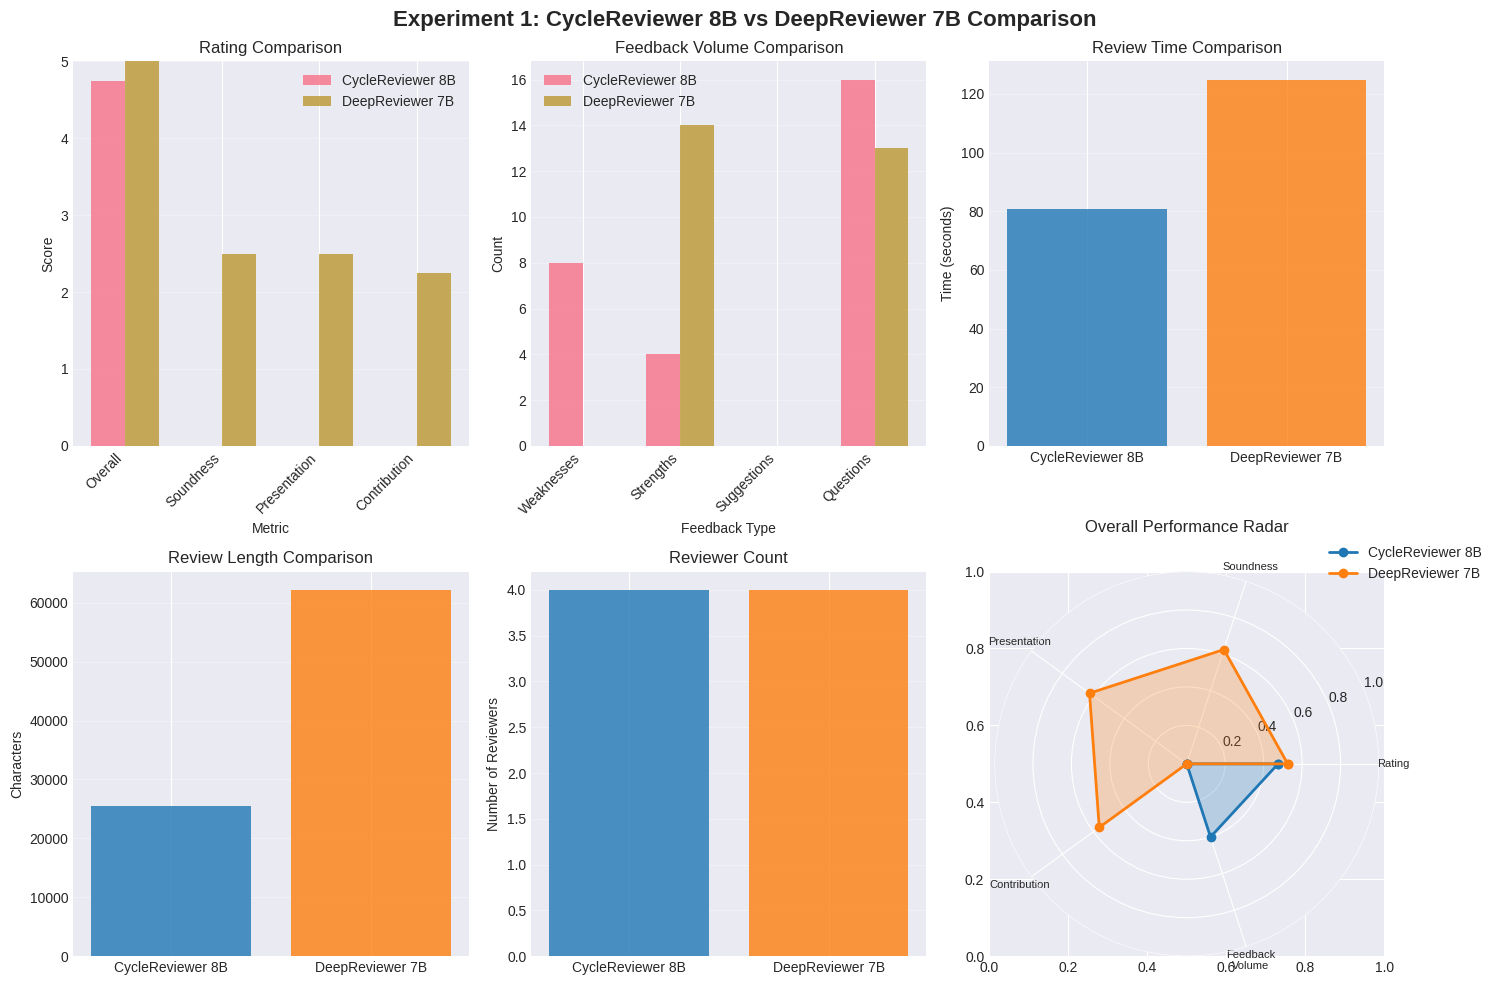

In [29]:
# 可视化对比结果
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Experiment 1: CycleReviewer 8B vs DeepReviewer 7B Comparison', fontsize=16, fontweight='bold')

# 1. 评分对比
metrics_to_plot = ['avg_rating', 'avg_soundness', 'avg_presentation', 'avg_contribution']
x_pos = np.arange(len(metrics_to_plot))
width = 0.35

cycle_scores = [cycle_metrics[m] for m in metrics_to_plot]
deep_scores = [deep_metrics[m] for m in metrics_to_plot]

axes[0, 0].bar(x_pos - width/2, cycle_scores, width, label='CycleReviewer 8B', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, deep_scores, width, label='DeepReviewer 7B', alpha=0.8)
axes[0, 0].set_xlabel('Metric')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Rating Comparison')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(['Overall', 'Soundness', 'Presentation', 'Contribution'], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 5])
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. 问题和建议数量对比
feedback_metrics = ['total_weaknesses', 'total_strengths', 'total_suggestions', 'total_questions']
x_pos2 = np.arange(len(feedback_metrics))

cycle_feedback = [cycle_metrics[m] for m in feedback_metrics]
deep_feedback = [deep_metrics[m] for m in feedback_metrics]

axes[0, 1].bar(x_pos2 - width/2, cycle_feedback, width, label='CycleReviewer 8B', alpha=0.8)
axes[0, 1].bar(x_pos2 + width/2, deep_feedback, width, label='DeepReviewer 7B', alpha=0.8)
axes[0, 1].set_xlabel('Feedback Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Feedback Volume Comparison')
axes[0, 1].set_xticks(x_pos2)
axes[0, 1].set_xticklabels(['Weaknesses', 'Strengths', 'Suggestions', 'Questions'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. 评审时间对比
axes[0, 2].bar(['CycleReviewer 8B', 'DeepReviewer 7B'], 
               [cycle_metrics['review_time'], deep_metrics['review_time']], 
               alpha=0.8, color=['#1f77b4', '#ff7f0e'])
axes[0, 2].set_ylabel('Time (seconds)')
axes[0, 2].set_title('Review Time Comparison')
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. 评审长度对比
axes[1, 0].bar(['CycleReviewer 8B', 'DeepReviewer 7B'], 
               [cycle_metrics['review_length'], deep_metrics['review_length']], 
               alpha=0.8, color=['#1f77b4', '#ff7f0e'])
axes[1, 0].set_ylabel('Characters')
axes[1, 0].set_title('Review Length Comparison')
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. 审稿人数量
axes[1, 1].bar(['CycleReviewer 8B', 'DeepReviewer 7B'], 
               [cycle_metrics['num_reviewers'], deep_metrics['num_reviewers']], 
               alpha=0.8, color=['#1f77b4', '#ff7f0e'])
axes[1, 1].set_ylabel('Number of Reviewers')
axes[1, 1].set_title('Reviewer Count')
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. 综合对比雷达图
from math import pi

categories = ['Rating', 'Soundness', 'Presentation', 'Contribution', 'Feedback\nVolume']
N = len(categories)

# 归一化数据到0-1范围
cycle_radar = [
    cycle_metrics['avg_rating'] / 10,
    cycle_metrics['avg_soundness'] / 4,
    cycle_metrics['avg_presentation'] / 4,
    cycle_metrics['avg_contribution'] / 4,
    (cycle_metrics['total_weaknesses'] + cycle_metrics['total_suggestions']) / 20
]
deep_radar = [
    deep_metrics['avg_rating'] / 10,
    deep_metrics['avg_soundness'] / 4,
    deep_metrics['avg_presentation'] / 4,
    deep_metrics['avg_contribution'] / 4,
    (deep_metrics['total_weaknesses'] + deep_metrics['total_suggestions']) / 20
]

angles = [n / float(N) * 2 * pi for n in range(N)]
cycle_radar += cycle_radar[:1]
deep_radar += deep_radar[:1]
angles += angles[:1]

ax = plt.subplot(2, 3, 6, projection='polar')
ax.plot(angles, cycle_radar, 'o-', linewidth=2, label='CycleReviewer 8B', color='#1f77b4')
ax.fill(angles, cycle_radar, alpha=0.25, color='#1f77b4')
ax.plot(angles, deep_radar, 'o-', linewidth=2, label='DeepReviewer 7B', color='#ff7f0e')
ax.fill(angles, deep_radar, alpha=0.25, color='#ff7f0e')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=8)
ax.set_ylim(0, 1)
ax.set_title('Overall Performance Radar', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('experiment1_model_comparison.png', dpi=300, bbox_inches='tight')
print("\n图表已保存为 'experiment1_model_comparison.png'")
plt.show()

## 实验1 结论

运行上述代码后，请根据结果填写：

In [30]:
# 计算关键差异
print("\n实验1 关键发现：")
print("="*60)

rating_diff = cycle_metrics['avg_rating'] - deep_metrics['avg_rating']
print(f"1. 评分差异: {rating_diff:+.2f} (CycleReviewer - DeepReviewer)")

weakness_diff = cycle_metrics['total_weaknesses'] - deep_metrics['total_weaknesses']
print(f"2. 发现的问题数量差异: {weakness_diff:+d}")

time_diff_pct = (cycle_time - deep_time) / deep_time * 100
print(f"3. 评审时间差异: {time_diff_pct:+.1f}%")

length_diff_pct = (cycle_metrics['review_length'] - deep_metrics['review_length']) / deep_metrics['review_length'] * 100
print(f"4. 评审详细程度差异: {length_diff_pct:+.1f}%")

print("\n建议: 根据以上数据,分析哪个模型更严格/更全面/更高效")


实验1 关键发现：
1. 评分差异: -0.50 (CycleReviewer - DeepReviewer)
2. 发现的问题数量差异: +8
3. 评审时间差异: -35.2%
4. 评审详细程度差异: -58.9%

建议: 根据以上数据,分析哪个模型更严格/更全面/更高效


In [ ]:
# 释放实验1使用的模型，避免显存溢出
import gc
import torch

print("\n" + "="*60)
print("🧹 清理显存")
print("="*60)

# 显示清理前的显存状态
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(i) / 1024**3
        reserved = torch.cuda.memory_reserved(i) / 1024**3
        print(f"\nGPU {i} 清理前:")
        print(f"  已分配: {allocated:.2f} GB")
        print(f"  已保留: {reserved:.2f} GB")

# 删除模型对象
if 'cycle_reviewer' in globals():
    del cycle_reviewer
    print("\n✓ CycleReviewer 已删除")

if 'deep_reviewer' in globals():
    del deep_reviewer
    print("✓ DeepReviewer 已删除")

# 强制垃圾回收
gc.collect()
print("✓ 垃圾回收完成")

# 清空CUDA缓存
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("✓ CUDA缓存已清空")
    
    # 显示清理后的显存状态
    print("\n" + "-"*60)
    for i in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(i) / 1024**3
        reserved = torch.cuda.memory_reserved(i) / 1024**3
        print(f"\nGPU {i} 清理后:")
        print(f"  已分配: {allocated:.2f} GB")
        print(f"  已保留: {reserved:.2f} GB")

print("\n" + "="*60)
print("✅ 显存清理完成！可以安全运行实验2了")
print("="*60)

## 🧹 清理显存

为了避免显存溢出，在进入下一个实验前，我们需要释放实验1中使用的模型。

---

# 实验 2: 迭代改进实验

## 实验目的
验证 CycleResearcher 的核心机制：通过评审反馈迭代改进论文质量。

## 实验设计
1. 生成初始论文（Iteration 0）
2. 评审论文，记录评分和问题
3. 基于评审反馈重新生成论文（Iteration 1）
4. 再次评审，对比改进效果
5. 重复2-3轮迭代

## 评估指标
- 每次迭代的评分变化
- 问题数量的变化趋势
- 各维度（Soundness/Presentation/Contribution）的改进

In [ ]:
print("\n" + "="*60)
print("实验 2: 迭代改进实验")
print("="*60)

# 初始化 CycleResearcher
# 注意：如果显存不足，需要先运行上面的清理单元格
print("\n初始化 CycleResearcher...")

# 为CycleResearcher分配GPU（使用之前的配置）
if USE_SEPARATE_GPUS:
    # 使用第一个GPU
    os.environ['CUDA_VISIBLE_DEVICES'] = GPU_FOR_CYCLE_REVIEWER
    print(f"使用 GPU {GPU_FOR_CYCLE_REVIEWER}")

researcher = CycleResearcher(
    model_size="12B",
    device="cuda",
    tensor_parallel_size=1,
    gpu_memory_utilization=0.75,  # 降低显存占用
    max_model_len=32768
)

# 重新初始化 DeepReviewer 作为评审模型
# 使用第二个GPU
if USE_SEPARATE_GPUS:
    os.environ['CUDA_VISIBLE_DEVICES'] = GPU_FOR_DEEP_REVIEWER
    print(f"\n重新初始化 DeepReviewer (GPU {GPU_FOR_DEEP_REVIEWER})...")

from ai_researcher import DeepReviewer
reviewer_for_iteration = DeepReviewer(
    custom_model_name="WestlakeNLP/DeepReviewer-7B",
    device="cuda",
    tensor_parallel_size=1,
    gpu_memory_utilization=0.75
)

print("初始化完成！")


实验 2: 迭代改进实验

初始化 CycleResearcher...


The tokenizer you are loading from 'WestlakeNLP/CycleResearcher-ML-12B' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


INFO 01-27 22:33:46 [utils.py:263] non-default args: {'max_model_len': 32768, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'model': 'WestlakeNLP/CycleResearcher-ML-12B'}
INFO 01-27 22:33:51 [model.py:530] Resolved architecture: MistralForCausalLM
INFO 01-27 22:33:51 [model.py:1545] Using max model len 32768
INFO 01-27 22:33:51 [scheduler.py:229] Chunked prefill is enabled with max_num_batched_tokens=8192.


The tokenizer you are loading from 'WestlakeNLP/CycleResearcher-ML-12B' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


(EngineCore_DP0 pid=2840307) INFO 01-27 22:33:57 [core.py:97] Initializing a V1 LLM engine (v0.14.0) with config: model='WestlakeNLP/CycleResearcher-ML-12B', speculative_config=None, tokenizer='WestlakeNLP/CycleResearcher-ML-12B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detailed

(EngineCore_DP0 pid=2840307) Process EngineCore_DP0:
(EngineCore_DP0 pid=2840307) Traceback (most recent call last):
(EngineCore_DP0 pid=2840307)   File "/home/zhihang/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
(EngineCore_DP0 pid=2840307)     self.run()
(EngineCore_DP0 pid=2840307)   File "/home/zhihang/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/lib/python3.11/multiprocessing/process.py", line 108, in run
(EngineCore_DP0 pid=2840307)     self._target(*self._args, **self._kwargs)
(EngineCore_DP0 pid=2840307)   File "/data/zhihang/CycleResearcher/Researcher/.venv/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 940, in run_engine_core
(EngineCore_DP0 pid=2840307)     raise e
(EngineCore_DP0 pid=2840307)   File "/data/zhihang/CycleResearcher/Researcher/.venv/lib/python3.11/site-packages/vllm/v1/engine/core.py", line 927, in run_engine_core
(EngineCore_DP0 pid=2840307)     engine_core =

RuntimeError: Engine core initialization failed. See root cause above. Failed core proc(s): {}

In [ ]:
# 定义研究问题（可以修改为你感兴趣的主题）
research_question = "How can we improve the efficiency of transformer models for long-context processing?"

print(f"研究问题: {research_question}")
print(f"\n开始迭代实验...")

# 存储迭代结果
iteration_results = []
num_iterations = 3  # 进行3次迭代

current_paper = None
previous_review = None

for iteration in range(num_iterations):
    print(f"\n{'='*60}")
    print(f"Iteration {iteration}")
    print(f"{'='*60}")
    
    # 生成或改进论文
    if iteration == 0:
        # 第一次：生成初始论文
        print("\n[步骤 1/2] 生成初始论文...")
        start_time = time.time()
        paper_result = researcher.generate_paper(
            research_question=research_question,
            max_references=10
        )
        gen_time = time.time() - start_time
        current_paper = paper_result['latex']
        print(f"论文生成完成! 用时: {gen_time:.2f}秒")
        print(f"论文长度: {len(current_paper)} 字符")
    else:
        # 后续迭代：基于评审反馈改进论文
        print(f"\n[步骤 1/2] 基于评审反馈改进论文...")
        
        # 提取评审中的weaknesses和suggestions
        feedback = "Previous review feedback:\n"
        if previous_review and previous_review.get('reviews'):
            for i, rev in enumerate(previous_review['reviews']):
                feedback += f"\nReviewer {i+1}:\n"
                if 'weaknesses' in rev:
                    feedback += "Weaknesses:\n"
                    for w in rev['weaknesses']:
                        feedback += f"- {w}\n"
                if 'suggestions' in rev:
                    feedback += "Suggestions:\n"
                    for s in rev['suggestions']:
                        feedback += f"- {s}\n"
        
        # 重新生成论文（模拟改进过程）
        # 注意：实际的CycleResearcher可能需要特定的改进方法
        # 这里我们简化为重新生成，实际应用中应该有专门的revision方法
        start_time = time.time()
        paper_result = researcher.generate_paper(
            research_question=research_question + "\n\n" + feedback,
            max_references=10
        )
        gen_time = time.time() - start_time
        current_paper = paper_result['latex']
        print(f"论文改进完成! 用时: {gen_time:.2f}秒")
        print(f"论文长度: {len(current_paper)} 字符")
    
    # 评审当前版本的论文
    print(f"\n[步骤 2/2] 评审论文...")
    start_time = time.time()
    review_result = reviewer_for_iteration.evaluate(
        current_paper,
        mode="Standard Mode",
        reviewer_num=3
    )[0]
    review_time = time.time() - start_time
    print(f"评审完成! 用时: {review_time:.2f}秒")
    
    # 提取指标
    metrics = extract_metrics(review_result)
    metrics['iteration'] = iteration
    metrics['generation_time'] = gen_time
    metrics['review_time'] = review_time
    
    # 保存结果
    iteration_results.append(metrics)
    previous_review = review_result
    
    # 打印当前迭代的关键指标
    print(f"\nIteration {iteration} 关键指标:")
    print(f"  Overall Rating: {metrics['avg_rating']:.2f}")
    print(f"  Soundness: {metrics['avg_soundness']:.2f}")
    print(f"  Presentation: {metrics['avg_presentation']:.2f}")
    print(f"  Contribution: {metrics['avg_contribution']:.2f}")
    print(f"  Weaknesses Found: {metrics['total_weaknesses']}")
    print(f"  Suggestions Given: {metrics['total_suggestions']}")

print("\n迭代实验完成!")

In [ ]:
# 创建迭代结果DataFrame
exp2_df = pd.DataFrame(iteration_results)
print("\n迭代结果汇总:")
print(exp2_df[['iteration', 'avg_rating', 'avg_soundness', 'avg_presentation', 
               'avg_contribution', 'total_weaknesses', 'total_suggestions']])

In [ ]:
# 可视化迭代改进过程
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experiment 2: Iterative Improvement Analysis', fontsize=16, fontweight='bold')

iterations = exp2_df['iteration'].values

# 1. 评分变化趋势
axes[0, 0].plot(iterations, exp2_df['avg_rating'], 'o-', linewidth=2, markersize=8, label='Overall Rating')
axes[0, 0].plot(iterations, exp2_df['avg_soundness'], 's-', linewidth=2, markersize=8, label='Soundness')
axes[0, 0].plot(iterations, exp2_df['avg_presentation'], '^-', linewidth=2, markersize=8, label='Presentation')
axes[0, 0].plot(iterations, exp2_df['avg_contribution'], 'd-', linewidth=2, markersize=8, label='Contribution')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Rating Evolution Over Iterations')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(iterations)

# 2. 问题和建议数量变化
width = 0.35
x_pos = iterations
axes[0, 1].bar(x_pos - width/2, exp2_df['total_weaknesses'], width, label='Weaknesses', alpha=0.8)
axes[0, 1].bar(x_pos + width/2, exp2_df['total_suggestions'], width, label='Suggestions', alpha=0.8)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Weaknesses and Suggestions Trend')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_xticks(iterations)

# 3. 评分改进百分比（相对于初始版本）
if len(exp2_df) > 1:
    initial_rating = exp2_df.iloc[0]['avg_rating']
    rating_improvement = [(r - initial_rating) / initial_rating * 100 if initial_rating > 0 else 0 
                          for r in exp2_df['avg_rating']]
    
    axes[1, 0].bar(iterations, rating_improvement, alpha=0.8, color='green')
    axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('Improvement (%)')
    axes[1, 0].set_title('Rating Improvement vs Initial Version')
    axes[1, 0].grid(axis='y', alpha=0.3)
    axes[1, 0].set_xticks(iterations)
    
    # 在柱状图上显示数值
    for i, v in enumerate(rating_improvement):
        axes[1, 0].text(iterations[i], v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

# 4. 综合质量指标（加权平均）
# 综合质量 = (avg_rating * 0.4 + avg_soundness * 0.2 + avg_presentation * 0.2 + avg_contribution * 0.2)
exp2_df['composite_quality'] = (
    exp2_df['avg_rating'] * 0.4 + 
    exp2_df['avg_soundness'] * 0.2 + 
    exp2_df['avg_presentation'] * 0.2 + 
    exp2_df['avg_contribution'] * 0.2
)

axes[1, 1].plot(iterations, exp2_df['composite_quality'], 'o-', linewidth=3, 
                markersize=10, color='purple', label='Composite Quality')
axes[1, 1].fill_between(iterations, exp2_df['composite_quality'], alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Composite Quality Score')
axes[1, 1].set_title('Overall Quality Progression')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(iterations)
axes[1, 1].legend()

# 在折线上标注数值
for i, v in enumerate(exp2_df['composite_quality']):
    axes[1, 1].text(iterations[i], v + 0.05, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('experiment2_iterative_improvement.png', dpi=300, bbox_inches='tight')
print("\n图表已保存为 'experiment2_iterative_improvement.png'")
plt.show()

In [ ]:
# 计算改进统计
if len(exp2_df) > 1:
    print("\n实验2 关键发现：")
    print("="*60)
    
    initial = exp2_df.iloc[0]
    final = exp2_df.iloc[-1]
    
    rating_change = final['avg_rating'] - initial['avg_rating']
    rating_change_pct = (rating_change / initial['avg_rating'] * 100) if initial['avg_rating'] > 0 else 0
    print(f"1. 总体评分改进: {rating_change:+.2f} ({rating_change_pct:+.1f}%)")
    
    soundness_change = final['avg_soundness'] - initial['avg_soundness']
    print(f"2. Soundness改进: {soundness_change:+.2f}")
    
    presentation_change = final['avg_presentation'] - initial['avg_presentation']
    print(f"3. Presentation改进: {presentation_change:+.2f}")
    
    contribution_change = final['avg_contribution'] - initial['avg_contribution']
    print(f"4. Contribution改进: {contribution_change:+.2f}")
    
    weakness_reduction = initial['total_weaknesses'] - final['total_weaknesses']
    print(f"5. 问题减少: {weakness_reduction:+d}")
    
    quality_improvement = final['composite_quality'] - initial['composite_quality']
    quality_improvement_pct = (quality_improvement / initial['composite_quality'] * 100) if initial['composite_quality'] > 0 else 0
    print(f"6. 综合质量提升: {quality_improvement:+.2f} ({quality_improvement_pct:+.1f}%)")
    
    print("\n结论: 迭代机制" + ("有效" if rating_change > 0 else "效果不明显"))
else:
    print("需要至少2次迭代才能计算改进")

In [ ]:
# 清理实验2使用的模型
print("\n" + "="*60)
print("🧹 清理显存（实验2）")
print("="*60)

if 'researcher' in globals():
    del researcher
    print("✓ CycleResearcher 已删除")

if 'reviewer_for_iteration' in globals():
    del reviewer_for_iteration
    print("✓ DeepReviewer (iteration) 已删除")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("✓ 显存已清理")

print("="*60)

## 🧹 清理显存（实验2结束）

---

# 实验 4: 评审模式对比实验

## 实验目的
对比 **Fast Mode** 和 **Standard Mode** 在评审质量和效率上的差异。

## 实验设计
- 使用相同的论文
- 分别用 Fast Mode 和 Standard Mode 评审
- 对比评审时间、详细程度、发现问题的数量

## 评估指标
- 评审时间
- 评审长度
- 发现的问题和建议数量
- 评分差异

In [ ]:
print("\n" + "="*60)
print("实验 4: 评审模式对比")
print("="*60)

# 重新初始化 DeepReviewer（如果之前被删除了）
if 'deep_reviewer' not in globals():
    print("\n重新初始化 DeepReviewer...")
    if USE_SEPARATE_GPUS:
        os.environ['CUDA_VISIBLE_DEVICES'] = GPU_FOR_DEEP_REVIEWER
        print(f"使用 GPU {GPU_FOR_DEEP_REVIEWER}")
    
    from ai_researcher import DeepReviewer
    deep_reviewer = DeepReviewer(
        custom_model_name="WestlakeNLP/DeepReviewer-7B",
        device="cuda",
        tensor_parallel_size=1,
        gpu_memory_utilization=0.75
    )
    print("✓ DeepReviewer 初始化完成")

# 使用之前的test_paper
print(f"\n测试论文: {test_paper['title']}")

# Fast Mode 评审
# DeepReviewer.evaluate() 接受列表作为输入，返回列表结果
print("\n[1/2] Fast Mode 评审中...")
start_time = time.time()
fast_mode_results = deep_reviewer.evaluate(
    [test_paper['latex']],  # 传入列表
    mode="Fast Mode"
)
fast_mode_review = fast_mode_results[0]  # 取第一个结果
fast_mode_time = time.time() - start_time
print(f"Fast Mode 完成! 用时: {fast_mode_time:.2f}秒")

# Standard Mode 评审 (3 reviewers)
print("\n[2/2] Standard Mode 评审中...")
start_time = time.time()
standard_mode_results = deep_reviewer.evaluate(
    [test_paper['latex']],  # 传入列表
    mode="Standard Mode",
    reviewer_num=3
)
standard_mode_review = standard_mode_results[0]  # 取第一个结果
standard_mode_time = time.time() - start_time
print(f"Standard Mode 完成! 用时: {standard_mode_time:.2f}秒")

print("\n评审完成!")

In [ ]:
# 提取并对比指标
fast_metrics = extract_metrics(fast_mode_review)
standard_metrics = extract_metrics(standard_mode_review)

fast_metrics['review_time'] = fast_mode_time
standard_metrics['review_time'] = standard_mode_time

print_metrics(fast_metrics, "Fast Mode Metrics")
print_metrics(standard_metrics, "Standard Mode Metrics")

# 创建对比DataFrame
exp4_comparison = pd.DataFrame({
    'Fast Mode': fast_metrics,
    'Standard Mode': standard_metrics
})

print("\n模式对比:")
print(exp4_comparison.T)

In [ ]:
# 可视化模式对比
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Experiment 4: Fast Mode vs Standard Mode Comparison', fontsize=16, fontweight='bold')

# 1. 评审时间对比
axes[0, 0].bar(['Fast Mode', 'Standard Mode'], 
               [fast_metrics['review_time'], standard_metrics['review_time']], 
               alpha=0.8, color=['#2ecc71', '#3498db'])
axes[0, 0].set_ylabel('Time (seconds)')
axes[0, 0].set_title('Review Time Comparison')
axes[0, 0].grid(axis='y', alpha=0.3)

# 在柱状图上显示数值
for i, (mode, time) in enumerate([('Fast', fast_metrics['review_time']), 
                                    ('Standard', standard_metrics['review_time'])]):
    axes[0, 0].text(i, time + 5, f"{time:.1f}s", ha='center', va='bottom')

# 2. 评审长度对比
axes[0, 1].bar(['Fast Mode', 'Standard Mode'], 
               [fast_metrics['review_length'], standard_metrics['review_length']], 
               alpha=0.8, color=['#2ecc71', '#3498db'])
axes[0, 1].set_ylabel('Characters')
axes[0, 1].set_title('Review Length Comparison')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. 审稿人数量
axes[0, 2].bar(['Fast Mode', 'Standard Mode'], 
               [fast_metrics['num_reviewers'], standard_metrics['num_reviewers']], 
               alpha=0.8, color=['#2ecc71', '#3498db'])
axes[0, 2].set_ylabel('Number of Reviewers')
axes[0, 2].set_title('Number of Simulated Reviewers')
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. 评分对比
score_metrics = ['avg_rating', 'avg_soundness', 'avg_presentation', 'avg_contribution']
x_pos = np.arange(len(score_metrics))
width = 0.35

fast_scores = [fast_metrics[m] for m in score_metrics]
standard_scores = [standard_metrics[m] for m in score_metrics]

axes[1, 0].bar(x_pos - width/2, fast_scores, width, label='Fast Mode', alpha=0.8, color='#2ecc71')
axes[1, 0].bar(x_pos + width/2, standard_scores, width, label='Standard Mode', alpha=0.8, color='#3498db')
axes[1, 0].set_xlabel('Metric')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Rating Comparison')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(['Overall', 'Soundness', 'Presentation', 'Contribution'], rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. 反馈数量对比
feedback_metrics = ['total_weaknesses', 'total_strengths', 'total_suggestions', 'total_questions']
x_pos2 = np.arange(len(feedback_metrics))

fast_feedback = [fast_metrics[m] for m in feedback_metrics]
standard_feedback = [standard_metrics[m] for m in feedback_metrics]

axes[1, 1].bar(x_pos2 - width/2, fast_feedback, width, label='Fast Mode', alpha=0.8, color='#2ecc71')
axes[1, 1].bar(x_pos2 + width/2, standard_feedback, width, label='Standard Mode', alpha=0.8, color='#3498db')
axes[1, 1].set_xlabel('Feedback Type')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Feedback Volume Comparison')
axes[1, 1].set_xticks(x_pos2)
axes[1, 1].set_xticklabels(['Weaknesses', 'Strengths', 'Suggestions', 'Questions'], rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. 效率 vs 质量权衡分析
# X轴: 评审时间, Y轴: 综合质量分数
fast_quality = fast_metrics['avg_rating']
standard_quality = standard_metrics['avg_rating']

axes[1, 2].scatter([fast_metrics['review_time']], [fast_quality], 
                   s=200, alpha=0.7, color='#2ecc71', label='Fast Mode', marker='o')
axes[1, 2].scatter([standard_metrics['review_time']], [standard_quality], 
                   s=200, alpha=0.7, color='#3498db', label='Standard Mode', marker='s')

# 添加标注
axes[1, 2].annotate('Fast Mode', 
                    xy=(fast_metrics['review_time'], fast_quality),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, ha='left')
axes[1, 2].annotate('Standard Mode', 
                    xy=(standard_metrics['review_time'], standard_quality),
                    xytext=(10, -15), textcoords='offset points',
                    fontsize=10, ha='left')

axes[1, 2].set_xlabel('Review Time (seconds)')
axes[1, 2].set_ylabel('Overall Rating')
axes[1, 2].set_title('Efficiency vs Quality Trade-off')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('experiment4_mode_comparison.png', dpi=300, bbox_inches='tight')
print("\n图表已保存为 'experiment4_mode_comparison.png'")
plt.show()

In [ ]:
# 计算效率指标
print("\n实验4 关键发现：")
print("="*60)

time_speedup = standard_metrics['review_time'] / fast_metrics['review_time']
print(f"1. Fast Mode 速度提升: {time_speedup:.2f}x")

detail_ratio = standard_metrics['review_length'] / fast_metrics['review_length']
print(f"2. Standard Mode 详细程度: {detail_ratio:.2f}x (相对于Fast Mode)")

rating_diff = standard_metrics['avg_rating'] - fast_metrics['avg_rating']
print(f"3. 评分差异: {rating_diff:+.2f} (Standard - Fast)")

feedback_fast = fast_metrics['total_weaknesses'] + fast_metrics['total_suggestions']
feedback_standard = standard_metrics['total_weaknesses'] + standard_metrics['total_suggestions']
feedback_ratio = feedback_standard / feedback_fast if feedback_fast > 0 else 0
print(f"4. Standard Mode 反馈量: {feedback_ratio:.2f}x (相对于Fast Mode)")

# 计算性价比 (质量/时间)
fast_efficiency = fast_quality / fast_metrics['review_time']
standard_efficiency = standard_quality / standard_metrics['review_time']
print(f"\n5. 效率对比 (评分/秒):")
print(f"   Fast Mode: {fast_efficiency:.4f}")
print(f"   Standard Mode: {standard_efficiency:.4f}")

print("\n建议使用场景:")
print("  - Fast Mode: 快速筛选、初步评估")
print("  - Standard Mode: 正式评审、需要详细反馈")

---

# 综合实验报告

## 导出实验结果数据

In [ ]:
# 保存所有实验数据到JSON文件
experiment_report = {
    'timestamp': datetime.now().isoformat(),
    'experiment_1_model_comparison': {
        'cyclereviewer_8b': cycle_metrics,
        'deepreviewer_7b': deep_metrics
    },
    'experiment_2_iterative_improvement': {
        'iterations': iteration_results,
        'research_question': research_question
    },
    'experiment_4_mode_comparison': {
        'fast_mode': fast_metrics,
        'standard_mode': standard_metrics
    }
}

with open('experiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(experiment_report, f, indent=2, ensure_ascii=False)

print("实验结果已保存到 'experiment_results.json'")

# 同时保存为Excel格式，方便查看
with pd.ExcelWriter('experiment_results.xlsx', engine='openpyxl') as writer:
    # 实验1
    exp1_comparison.T.to_excel(writer, sheet_name='Exp1_Model_Comparison')
    
    # 实验2
    exp2_df.to_excel(writer, sheet_name='Exp2_Iteration', index=False)
    
    # 实验4
    exp4_comparison.T.to_excel(writer, sheet_name='Exp4_Mode_Comparison')

print("实验结果已保存到 'experiment_results.xlsx'")

## 实验总结

运行完所有实验后，你可以向导师汇报以下内容：

### 1. 实验1：模型对比
- CycleReviewer 8B 和 DeepReviewer 7B 的评审差异
- 哪个模型更严格/更全面
- 评审时间和详细程度的权衡

### 2. 实验2：迭代改进
- 论文质量的逐次提升（用数据说话）
- 各维度的改进情况
- 验证了CycleResearcher的核心理念

### 3. 实验4：评审模式对比
- Fast Mode vs Standard Mode 的效率和质量权衡
- 不同场景下的最佳选择
- 性价比分析

### 4. 下一步工作建议
- 扩展到更多研究领域
- 测试不同参数配置
- 与人工评审对比（如果可能）
- 探索更多迭代轮次的效果